## Лабораторная работа №3
### Компьютерное зрение

**Выполнил:** Изгородин Илья Юрьевич  
**Группа:** ФИТ-232  
**Факультет:** ФИТиКС ОмГТУ  

*Омск, 2026*

Перед началом выполнения работы устанавливаю и импотрирую библиотеки, необходимые для поставленных заданий

In [75]:
!pip install matplotlib==3.10.8 numpy==2.4.2 opencv-python==4.13.0.92 opencv-contrib-python==4.13.0.92

������� ������� ��������: 1251


In [76]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

Функция для удобного отображения изображений (заимствовано с 1 ЛР)

In [77]:
def imsh(img, is_gray=False):
    fig = plt.figure(frameon=False)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)
    ax.imshow(img, cmap='gray' if is_gray else None)
    plt.show()

## Загрузка изображения

Загружаю тестовое изображение

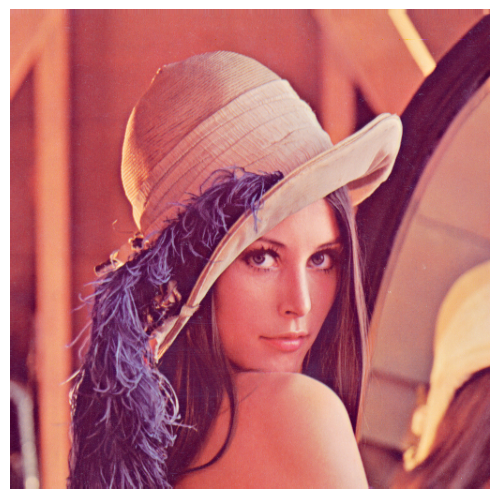

In [78]:
img = cv2.cvtColor(cv2.imread("Lenna.png"), cv2.COLOR_BGR2RGB)
imsh(img)

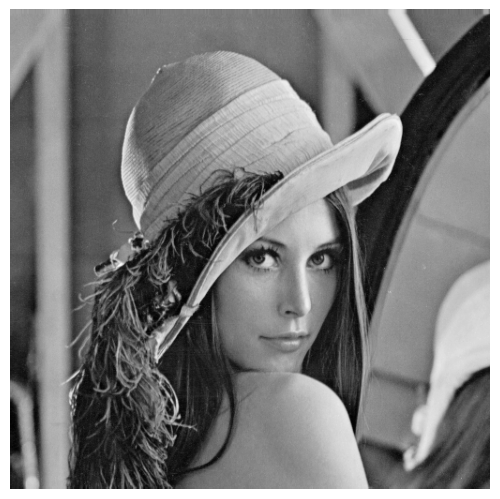

In [79]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
imsh(img_gray, True)

# Задание 1 Работа с шумом

Реализую функции шума: соль и перец, гауссов шум.

In [80]:
def add_salt_pepper(img, p_salt, p_pepper):
    noisy = img.copy()
    h, w = img.shape[:2]
    
    total = p_salt + p_pepper
    if total > 1:
        p_salt = p_salt / total
        p_pepper = p_pepper / total
    
    rand = np.random.rand(h, w)
    
    salt_mask = rand < p_salt
    pepper_mask = (rand >= p_salt) & (rand < p_salt + p_pepper)
    
    if len(img.shape) == 3:
        noisy[salt_mask] = [255, 255, 255]
        noisy[pepper_mask] = [0, 0, 0]
    else:
        noisy[salt_mask] = 255
        noisy[pepper_mask] = 0
    
    return noisy

In [81]:
def add_gaussian_noise(img, mean, sigma):
    noise = np.random.normal(mean, sigma, img.shape)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

Генерирую шумы на изображении

In [82]:
sp_1 = add_salt_pepper(img, 0.01, 0.01)
sp_2 = add_salt_pepper(img, 0.05, 0.05)
sp_3 = add_salt_pepper(img, 0.1, 0.1)
sp_params = [0.01, 0.05, 0.1]

In [83]:
gauss_1 = add_gaussian_noise(img, 0, 10)
gauss_2 = add_gaussian_noise(img, 0, 25)
gauss_3 = add_gaussian_noise(img, 0, 50)
gauss_params = [10, 25, 50]

Вывожу изображения с шумом

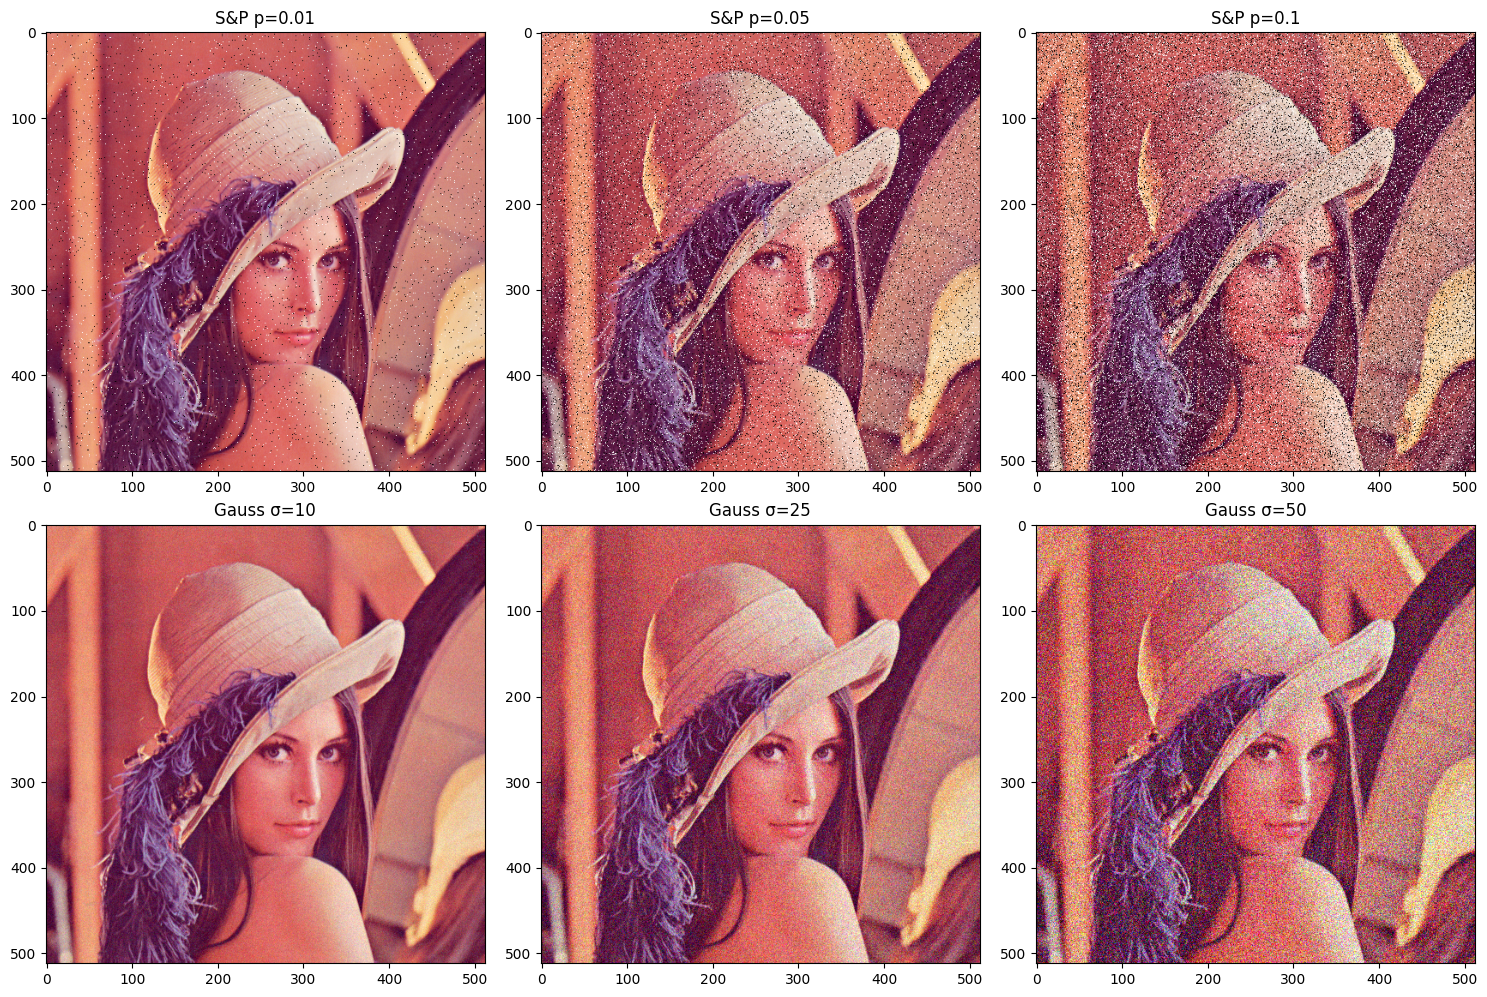

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes[0]): ax.imshow([sp_1, sp_2, sp_3][i]); ax.set_title(f'S&P p={sp_params[i]}')
for i, ax in enumerate(axes[1]): ax.imshow([gauss_1, gauss_2, gauss_3][i]); ax.set_title(f'Gauss σ={gauss_params[i]}')
plt.tight_layout()
plt.show()

In [ ]:
def create_box_kernel(k_size):
    return np.ones((k_size, k_size), dtype=np.float32) / (k_size * k_size)

def create_gaussian_kernel(k_size, sigma):
    ax = np.linspace(-(k_size // 2), k_size // 2, k_size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def apply_convolution(img, kernel):
    is_color = len(img.shape) == 3
    h, w = img.shape[:2]
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    if is_color:
        result = np.zeros_like(img, dtype=np.float32)
        for c in range(img.shape[2]):
            padded = np.pad(img[:, :, c].astype(np.float32), 
                          ((pad_h, pad_h), (pad_w, pad_w)), 
                          mode='reflect')
            for i in range(h):
                for j in range(w):
                    region = padded[i:i+kh, j:j+kw]
                    result[i, j, c] = np.sum(region * kernel)
    else:
        result = np.zeros((h, w), dtype=np.float32)
        padded = np.pad(img.astype(np.float32), 
                       ((pad_h, pad_h), (pad_w, pad_w)), 
                       mode='reflect')
        for i in range(h):
            for j in range(w):
                region = padded[i:i+kh, j:j+kw]
                result[i, j] = np.sum(region * kernel)
    
    return np.clip(result, 0, 255).astype(np.uint8)

def apply_median_filter(img, k_size):
    is_color = len(img.shape) == 3
    h, w = img.shape[:2]
    pad = k_size // 2
    
    if is_color:
        result = np.zeros_like(img)
        for c in range(img.shape[2]):
            padded = np.pad(img[:, :, c], 
                          ((pad, pad), (pad, pad)), 
                          mode='reflect')
            for i in range(h):
                for j in range(w):
                    region = padded[i:i+k_size, j:j+k_size]
                    result[i, j, c] = np.median(region)
    else:
        result = np.zeros_like(img)
        padded = np.pad(img, ((pad, pad), (pad, pad)), mode='reflect')
        for i in range(h):
            for j in range(w):
                region = padded[i:i+k_size, j:j+k_size]
                result[i, j] = np.median(region)
    
    return result.astype(np.uint8)

In [86]:
box_k = create_box_kernel(3)
gauss_k_small = create_gaussian_kernel(3, 1)
gauss_k_large = create_gaussian_kernel(5, 2)

In [87]:
res_box_sp = apply_convolution(sp_2, box_k)
res_gauss_sp = apply_convolution(sp_2, gauss_k_large)
res_median_sp = apply_median_filter(sp_2, 3)

In [88]:
res_gauss_g1 = apply_convolution(gauss_2, gauss_k_small)
res_gauss_g2 = apply_convolution(gauss_2, gauss_k_large)

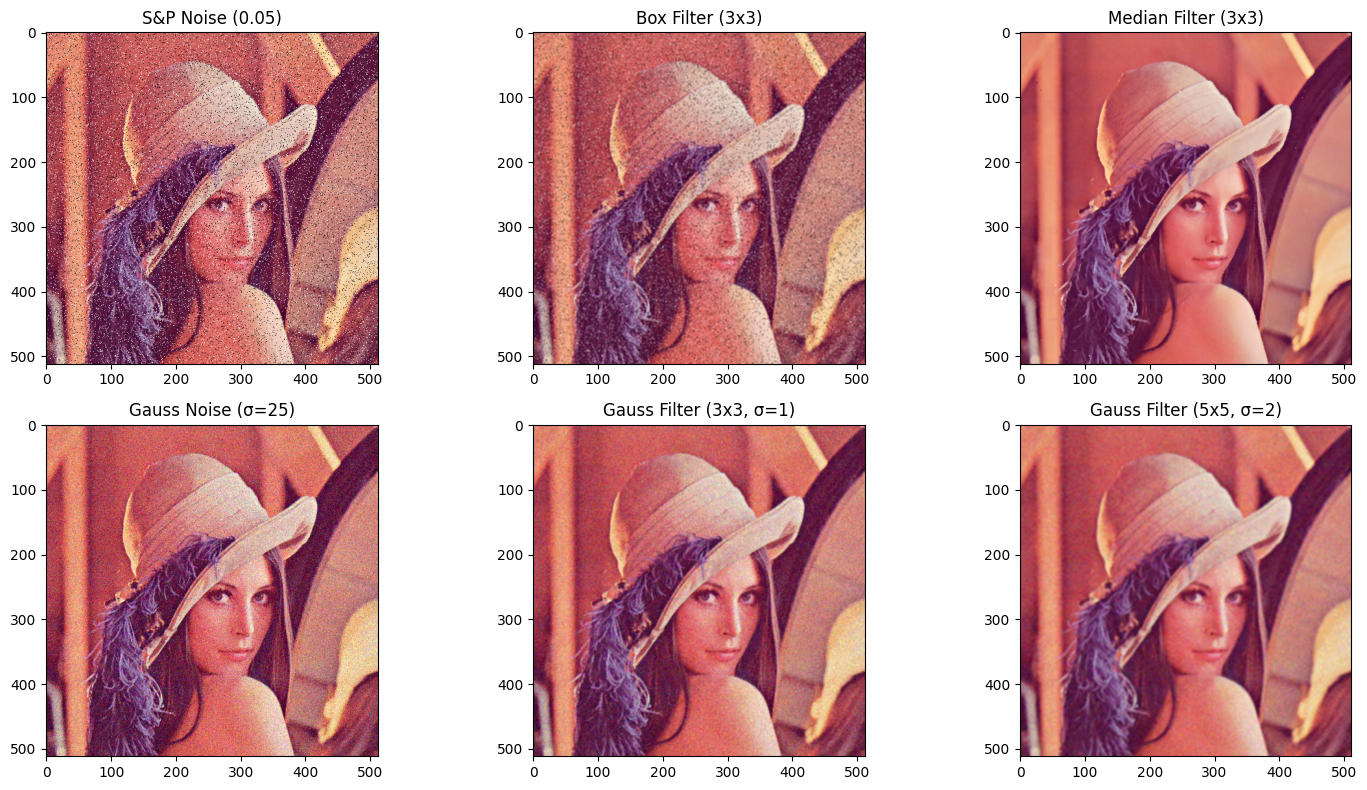

In [89]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(sp_2); axes[0, 0].set_title('S&P Noise (0.05)')
axes[0, 1].imshow(res_box_sp); axes[0, 1].set_title('Box Filter (3x3)')
axes[0, 2].imshow(res_median_sp); axes[0, 2].set_title('Median Filter (3x3)')

axes[1, 0].imshow(gauss_2); axes[1, 0].set_title('Gauss Noise (σ=25)')
axes[1, 1].imshow(res_gauss_g1); axes[1, 1].set_title('Gauss Filter (3x3, σ=1)')
axes[1, 2].imshow(res_gauss_g2); axes[1, 2].set_title('Gauss Filter (5x5, σ=2)')
plt.tight_layout()
plt.show()

# Задание 2 Детектор границ Canny



In [90]:
def sobel_x():
    return np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)

def sobel_y():
    return np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

def apply_convolution_float(img, kernel):
    is_color = len(img.shape) == 3
    h, w = img.shape[:2]
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    if is_color:
        result = np.zeros_like(img, dtype=np.float32)
        for c in range(img.shape[2]):
            padded = np.pad(img[:, :, c].astype(np.float32), 
                          ((pad_h, pad_h), (pad_w, pad_w)), 
                          mode='reflect')
            for i in range(h):
                for j in range(w):
                    region = padded[i:i+kh, j:j+kw]
                    result[i, j, c] = np.sum(region * kernel)
    else:
        result = np.zeros((h, w), dtype=np.float32)
        padded = np.pad(img.astype(np.float32), 
                       ((pad_h, pad_h), (pad_w, pad_w)), 
                       mode='reflect')
        for i in range(h):
            for j in range(w):
                region = padded[i:i+kh, j:j+kw]
                result[i, j] = np.sum(region * kernel)
    
    return result

def compute_gradients(img):
    kx, ky = sobel_x(), sobel_y()
    gx = apply_convolution_float(img, kx)
    gy = apply_convolution_float(img, ky)
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx)
    return gx, gy, magnitude, direction

def non_max_suppression(magnitude, direction):
    h, w = magnitude.shape
    res = np.zeros_like(magnitude)
    angle = np.rad2deg(direction) % 180
    
    for i in range(1, h-1):
        for j in range(1, w-1):
            a = angle[i, j]
            mag = magnitude[i, j]
            
            if (0 <= a < 22.5) or (157.5 <= a <= 180):
                neighbors = (magnitude[i, j+1], magnitude[i, j-1])
            elif 22.5 <= a < 67.5:
                neighbors = (magnitude[i+1, j-1], magnitude[i-1, j+1])
            elif 67.5 <= a < 112.5:
                neighbors = (magnitude[i+1, j], magnitude[i-1, j])
            else:
                neighbors = (magnitude[i-1, j-1], magnitude[i+1, j+1])
            
            if mag >= neighbors[0] and mag >= neighbors[1]:
                res[i, j] = mag
    
    return res

def threshold_hysteresis(img, low, high):
    strong = 255
    weak = 75
    
    strong_mask = img >= high
    weak_mask = (img >= low) & (img < high)
    
    res = np.zeros_like(img, dtype=np.uint8)
    res[strong_mask] = strong
    res[weak_mask] = weak
    
    h, w = img.shape
    changed = True
    while changed:
        changed = False
        for i in range(1, h-1):
            for j in range(1, w-1):
                if res[i, j] == weak:
                    if np.any(res[i-1:i+2, j-1:j+2] == strong):
                        res[i, j] = strong
                        changed = True
    
    res[res == weak] = 0
    return res

def canny_edge_detection(img, low_threshold=50, high_threshold=150):
    gx, gy, mag, dire = compute_gradients(img)
    mag_nms = non_max_suppression(mag, dire)
    edges = threshold_hysteresis(mag_nms, low_threshold, high_threshold)
    return gx, gy, mag, edges

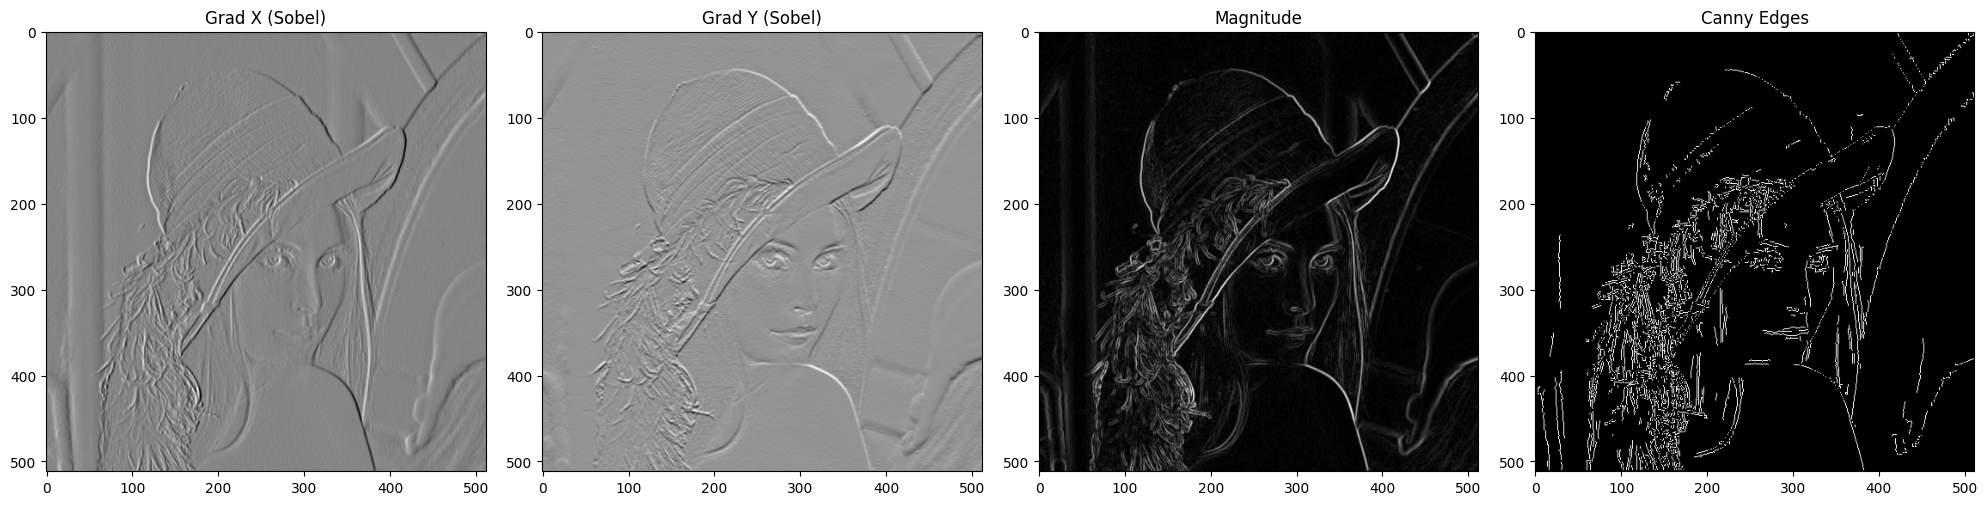

In [91]:
gx, gy, mag, dire = compute_gradients(img_gray)
mag_nms = non_max_suppression(mag, dire)
edges = threshold_hysteresis(mag_nms, 50, 150)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(gx, cmap='gray'); axes[0].set_title('Grad X (Sobel)')
axes[1].imshow(gy, cmap='gray'); axes[1].set_title('Grad Y (Sobel)')
axes[2].imshow(mag, cmap='gray'); axes[2].set_title('Magnitude')
axes[3].imshow(edges, cmap='gray'); axes[3].set_title('Canny Edges')
plt.tight_layout()
plt.show()

# Задание 3 Детектор углов Харриса

In [ ]:
def detect_harris(img, k=0.04, threshold_ratio=0.01, window_size=3):
    gx, gy, _, _ = compute_gradients(img)
    
    Ix2 = gx.astype(float) ** 2
    Iy2 = gy.astype(float) ** 2
    Ixy = gx.astype(float) * gy.astype(float)
    
    box = create_box_kernel(window_size)
    Sx2 = apply_convolution_float(Ix2, box)
    Sy2 = apply_convolution_float(Iy2, box)
    Sxy = apply_convolution_float(Ixy, box)
    
    det_M = Sx2 * Sy2 - Sxy ** 2
    trace_M = Sx2 + Sy2
    R = det_M - k * (trace_M ** 2)
    
    h, w = R.shape
    corners = np.zeros_like(R, dtype=bool)
    
    threshold = R.max() * threshold_ratio
    
    for i in range(1, h-1):
        for j in range(1, w-1):
            if R[i, j] > threshold:
                window = R[i-1:i+2, j-1:j+2]
                if R[i, j] == window.max():
                    corners[i, j] = True
    
    return corners, R

In [106]:
corners, R_map = detect_harris(img_gray, k=0.04, threshold_ratio=0.01)

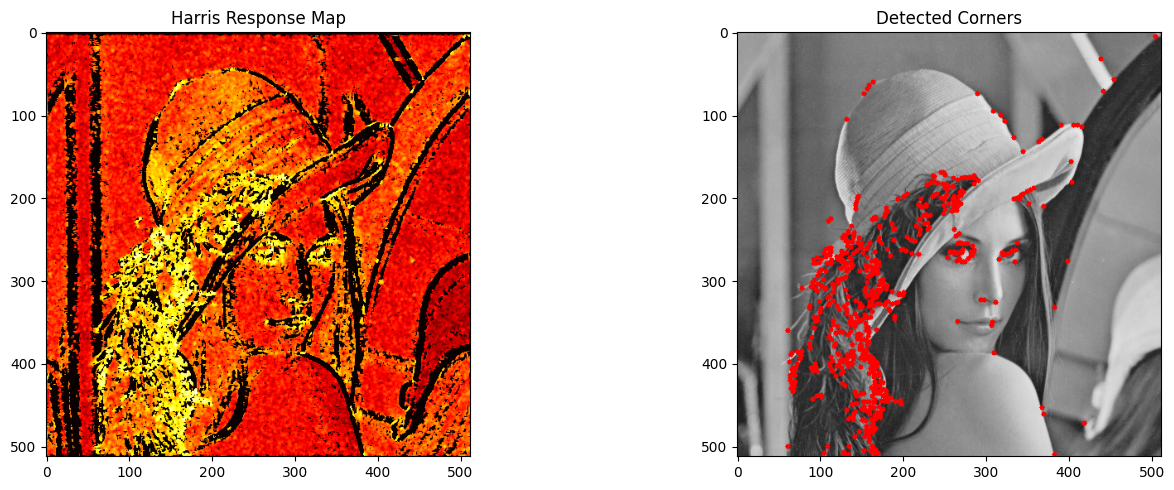

In [107]:
img_corners = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
ys, xs = np.where(corners)
for x, y in zip(xs, ys):
    cv2.circle(img_corners, (x, y), 3, (255, 0, 0), -1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

R_display = np.log1p(np.maximum(R_map, 0))
axes[0].imshow(R_display, cmap='hot')
axes[0].set_title('Harris Response Map')

axes[1].imshow(img_corners)
axes[1].set_title('Detected Corners')
plt.tight_layout()
plt.show()